![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Análisis de reducción de dimensionalidad: PCA y t-SNE
## Objetivo General
En este trabajo, se busca que pongas en práctica la aplicación de algoritmos de reducción de dimensionalidad. El objetivo es aplicar técnicas para reducir la dimensionalidad a 2D, graficar los resultados y seleccionar la mejor técnica para los datos. Además, deberás detallar los pasos a seguir para la reducción de dimensionalidad y analizar los resultados obtenidos.

### Objetivos específicos 
* Entender los métodos de t-SNE y PCA.
* Realizar la reducción de dimensionalidad utilizando t-SNE y PCA.
* Comparar los resultados obtenidos con ambos métodos.
* Aplicar LDA para reducir el dataset a una bolsa de palabras por cada etiqueta.

### Tareas a Realizar:
Debes realizar esta actividad en el Notebook adjunto. A medida que avances, completa el código solicitado y responde a las preguntas que se plantean.
Las tareas a realizar son:

* Reducción de Dimensionalidad con t-SNE y PCA:
* Completa el código proporcionado en el notebook.
* Responde a las preguntas finales sobre los resultados obtenidos.

#### Punto adicional: Aplicación de LDA:

Utiliza la técnica de LDA para generar una bolsa de palabras para cada una de las etiquetas.





### Coloca en este espacio el nombre del estudiante

Marcos Caballero Cortés

### Dataset

#### Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:
* Eliminación de nulos y duplicados
* Eliminación de URLs, emojis y menciones a los periódicos
* Eliminación de filas vacías
* Limpieza y homogeneización de datos.
* Convertir la totalidad del texto a minúscula
* Eliminar signos de puntuación
* Eliminar números
* Eliminar espacios en blanco adicionales
* Eliminar palabras con longitud menor a 2 caracteres
* Eliminar stopwords
* Tokenización
* Lematización

Proceso de extracción de características
* Conteo de palabras positivas (A)
* Conteo de palabras negativas (B)
* Conteo del número de bigrams más comunes (C)
* Conteo del número de menciones a otros usuarios (D)
* Categoría del sentimiento según librería ‘pysentimiento’ en español (E)
* Estandarización de las características (A_t,..E_t)
* Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel

### Lectura de datos

In [22]:
# Leer el archivo CSV
file_path = 'out.csv'
data = pd.read_csv(file_path)

# Obtener el número de filas y columnas
num_filas, num_columnas = data.shape

# Mostrar el número de filas y columnas
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 10000 filas y 22 columnas.


In [23]:
##Cuántas categorías hay en la columna label
# Contar el número de categorías únicas en la columna 'label'
num_categorias = data['label'].nunique()
# Mostrar el número de categorías
print(f"El dataset tiene {num_categorias} categorías en la columna 'label'.")

El dataset tiene 2 categorías en la columna 'label'.


In [24]:
# Obtener estadísticas descriptivas de las variables numéricas
estadisticas = data.describe()

print("Estadísticas descriptivas de las variables numéricas:")
print(estadisticas)

# Obtener la frecuencia de las categorías en la columna 'label'
frecuencia_categorias = data['label'].value_counts()
print("\nFrecuencia de las categorías en la columna 'label':")
print(frecuencia_categorias)

Estadísticas descriptivas de las variables numéricas:
                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571 

Al tener tantas columnas no podemos representar de forma legible todas las relacciones entre variables.

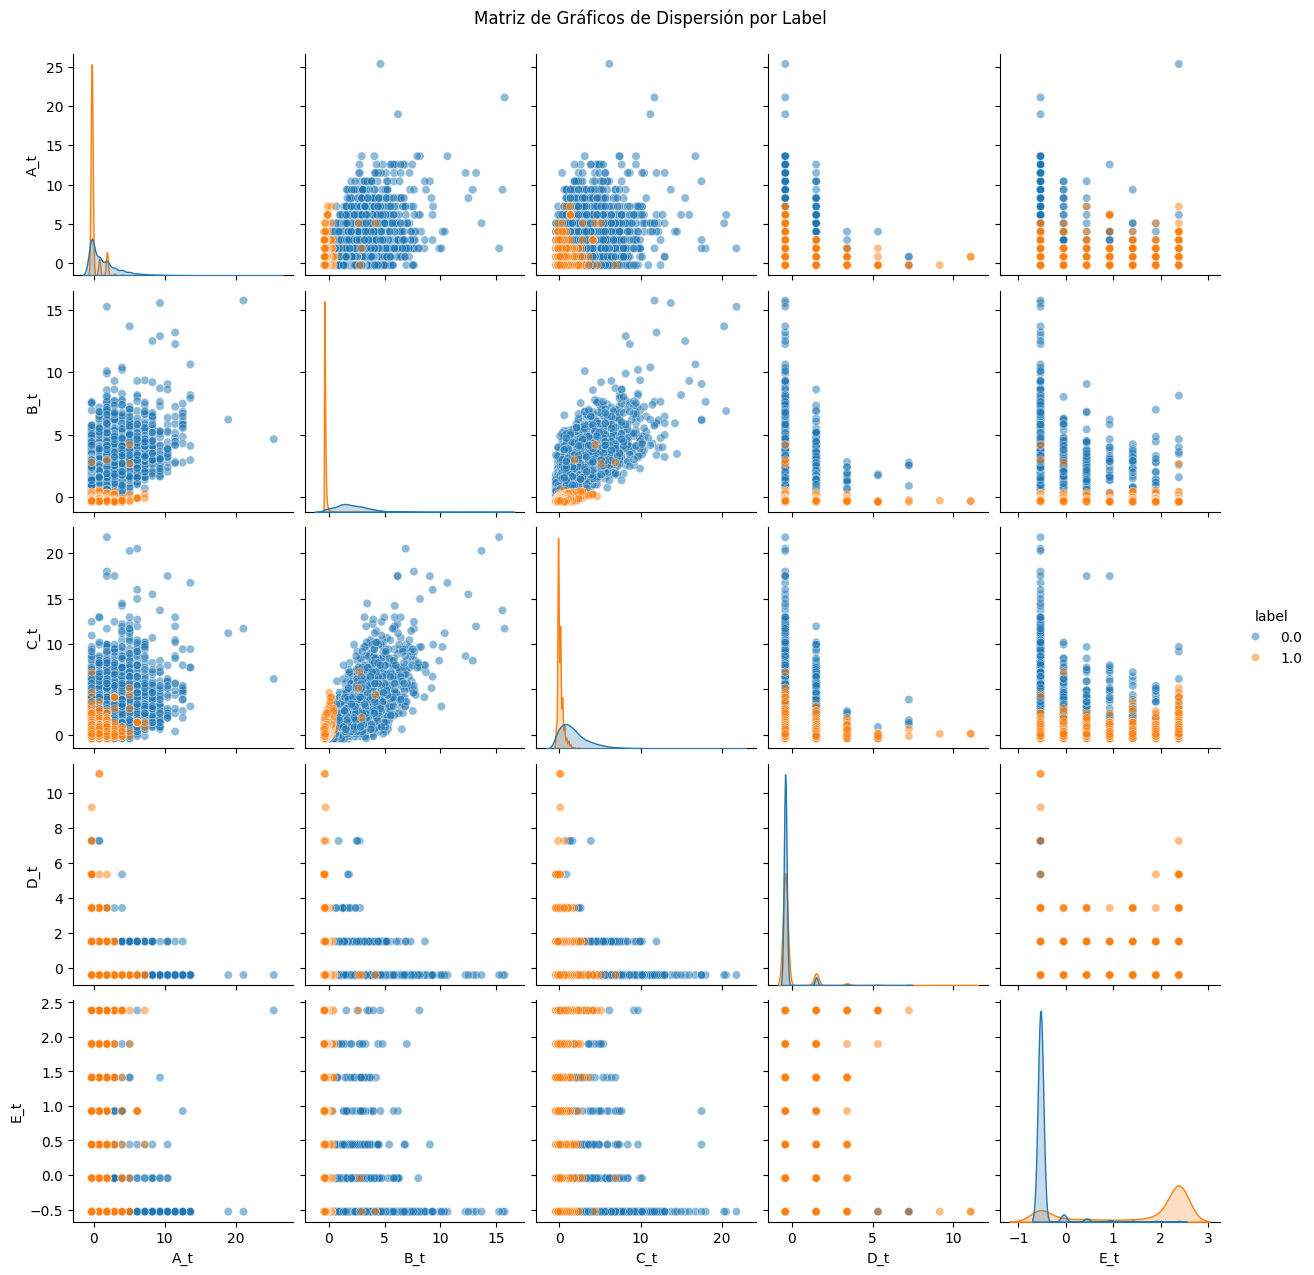

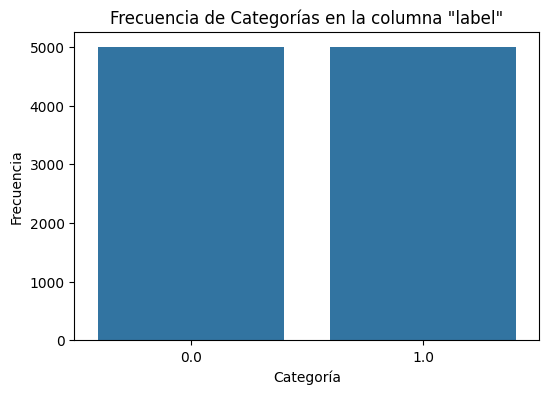

In [25]:
# Crear una matriz de gráficos de dispersión (pairplot)

columnas_seleccionadas = ['A_t', 'B_t', 'C_t', 'D_t', 'E_t', 'label']

# Crear la matriz de gráficos de dispersión (pairplot)
sns.pairplot(data[columnas_seleccionadas], hue='label', plot_kws={'alpha': 0.5})
plt.suptitle('Matriz de Gráficos de Dispersión por Label', y=1.02)
plt.show()

# Crear un gráfico de barras de la frecuencia de las categorías
frecuencia_categorias = data['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=frecuencia_categorias.index.astype(str), y=frecuencia_categorias.values)
plt.title('Frecuencia de Categorías en la columna "label"')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

Como se puede observar, el dataset está balanceado, con el mismo número de ejemplos para cada clase (label = 0 y label = 1). Esto es relevante porque evita sesgos durante el entrenamiento de modelos de clasificación.

En el pairplot generado, se aprecia que los datos se agrupan de forma distinta según la etiqueta asignada. Específicamente, los ejemplos con label = 1 tienden a concentrarse en valores más bajos para las variables analizadas, mientras que los de label = 0 se dispersan en valores más altos. Esto sugiere que las características numéricas extraídas reflejan diferencias reales entre los dos tipos de comentarios.

In [26]:
comentario = data.iloc[5001]['comentario']
label = data.iloc[5001]['label']

print(f"Comentario de la primera fila: {comentario}")
print(f"Label de la primera fila: {label}")

Comentario de la primera fila: cristinar,cifuent,podrio,haber,ser,presidenta,madrid,todavia,añorar,madrileño,visto,ayuso,podrio,haber,llegar,ser,presidenta,madrid,supuesto,nivel,estatal,quizas,tambien,mala,cabeza,hundio,futuro,politico,fango,imposible,regresar,necesidad,tenia,demostrar,habio,sacado,master,siquiera,casado,urdio,plan,amenaza,abuso,poder,falsificar,documento,oficial,penado,carcel,necesitar,carrera,politico,rematar,desastre,pillar,hurtar,uno,crema,facial,podrio,haber,pagar,tranquilamente,cleptomania,oculto,camar,indiscreta,destrozar,verguenza,libro,
Label de la primera fila: 1.0


Al inspeccionar manualmente un ejemplo con label = 1, observamos que el comentario contiene un lenguaje agresivo y acusatorio, con múltiples referencias negativas y términos peyorativos, lo que coincide con la interpretación de que esta clase representa comentarios de odio.

En consecuencia, podemos asumir que label = 0 corresponde a comentarios no ofensivos o neutros, mientras que label = 1 indica comentarios con contenido de odio, insultos o ataques personales.

In [27]:
# Eliminar columnas que empiecen por 'Valor_' y la columna 'comentario'
data_cleaned = data.drop(columns=[col for col in data.columns if col.startswith('Valor_') or col == 'comentario'])

# Mostrar las primeras filas del nuevo dataframe para verificar
print("\nPrimeras filas del dataframe limpio:")
print(data_cleaned.head(5))


Primeras filas del dataframe limpio:
   A   B   C  D  E  label       A_t       B_t        C_t       D_t       E_t
0  2  64  30  0  2    0.0  1.851102  2.759647   7.145831 -0.416577  0.440638
1  4  70  21  0  0    0.0  3.990202  3.054765   4.877255 -0.416577 -0.531099
2  4  88  50  0  0    0.0  3.990202  3.940120  12.187108 -0.416577 -0.531099
3  3  38  21  0  0    0.0  2.920652  1.480801   4.877255 -0.416577 -0.531099
4  0  59  17  0  0    0.0 -0.287998  2.513715   3.869000 -0.416577 -0.531099


In [28]:
# Estandarizar las columnas, excepto 'label'
features = data_cleaned.drop(columns=['label'])
labels = data_cleaned['label']

# Aplicar estandarización
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Crear nuevo DataFrame con las columnas estandarizadas
import pandas as pd
data_standardized = pd.DataFrame(features_scaled, columns=features.columns)
data_standardized['label'] = labels.values  # Añadir la columna 'label' de nuevo

# Verificar las primeras filas
print("\nPrimeras filas del dataframe estandarizado:")
print(data_standardized.head(5))



Primeras filas del dataframe estandarizado:
          A         B         C         D         E       A_t       B_t  \
0  0.598584  1.114413  3.324603 -0.258895 -0.073497  0.598584  1.114413   
1  1.746837  1.290828  2.094554 -0.258895 -0.806272  1.746837  1.290828   
2  1.746837  1.820075  6.058045 -0.258895 -0.806272  1.746837  1.820075   
3  1.172711  0.349946  2.094554 -0.258895 -0.806272  1.172711  0.349946   
4 -0.549669  0.967400  1.547866 -0.258895 -0.806272 -0.549669  0.967400   

        C_t       D_t       E_t  label  
0  3.324603 -0.258895 -0.073497    0.0  
1  2.094554 -0.258895 -0.806272    0.0  
2  6.058045 -0.258895 -0.806272    0.0  
3  2.094554 -0.258895 -0.806272    0.0  
4  1.547866 -0.258895 -0.806272    0.0  


In [29]:
# Separar las características y las etiquetas
df = data_standardized.copy()

# Eliminar columnas duplicadas: en este caso, quitamos las '_t'
columnas_a_quitar = ['A_t', 'B_t', 'C_t', 'D_t', 'E_t']
df = df.drop(columns=columnas_a_quitar)

# Separar características (X) y etiquetas (y)
X = df.drop(columns=['label'])
y = df['label']

# Verificar dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Verificar primeras filas
print("\nPrimeras filas de X:")
print(X.head())

print("\nPrimeras etiquetas (y):")
print(y.head())


Dimensiones de X: (10000, 5)
Dimensiones de y: (10000,)

Primeras filas de X:
          A         B         C         D         E
0  0.598584  1.114413  3.324603 -0.258895 -0.073497
1  1.746837  1.290828  2.094554 -0.258895 -0.806272
2  1.746837  1.820075  6.058045 -0.258895 -0.806272
3  1.172711  0.349946  2.094554 -0.258895 -0.806272
4 -0.549669  0.967400  1.547866 -0.258895 -0.806272

Primeras etiquetas (y):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: label, dtype: float64


### PCA

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crear un DataFrame con los resultados
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['label'] = y.values  # Añadir la etiqueta para graficar

# Verificar los primeros valores
print("Primeras filas del DataFrame con PCA:")
print(pca_df.head())


Primeras filas del DataFrame con PCA:
       PCA1      PCA2  label
0  2.731745  0.181775    0.0
1  3.007871  0.090378    0.0
2  5.418864  0.520701    0.0
3  2.202662  0.001223    0.0
4  1.480875 -0.221601    0.0


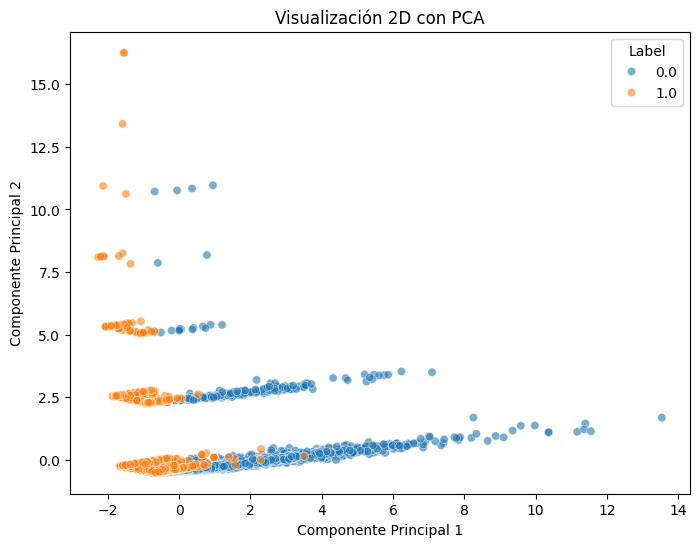

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='label', alpha=0.6)
plt.title('Visualización 2D con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Label')
plt.show()

In [32]:
# Aplicar PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# Crear un DataFrame con los resultados de PCA
pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PCA1', 'PCA2', 'PCA3'])
pca_3d_df['label'] = y.values

print("Primeras filas del DataFrame con PCA 3D:")
print(pca_3d_df.head())

Primeras filas del DataFrame con PCA 3D:
       PCA1      PCA2      PCA3  label
0  2.731745  0.181775  0.958968    0.0
1  3.007871  0.090378  0.664986    0.0
2  5.418864  0.520701  1.486550    0.0
3  2.202662  0.001223  0.398834    0.0
4  1.480875 -0.221601 -0.584350    0.0


In [33]:
# Visualizar los resultados de PCA
fig = px.scatter_3d(
    pca_3d_df,
    x='PCA1', y='PCA2', z='PCA3',
    color=pca_3d_df['label'].astype(str),
    title='Visualización 3D con PCA',
    opacity=0.6
)

fig.update_traces(marker=dict(size=2))  # Puedes ajustar el número (por ejemplo, 2 o 1.5 si quieres más pequeño)

fig.show()

In [34]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = model.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print(f"\nPrecisión (accuracy): {accuracy_score(y_test, y_pred):.2f}")

Matriz de confusión:
[[978  22]
 [ 18 982]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1000
         1.0       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


Precisión (accuracy): 0.98


#### Analice los resultados obtenidos por PCA

Se aplicó PCA con el objetivo de reducir la dimensionalidad del dataset a dos y tres dimensiones para facilitar la visualización y comprensión de la estructura de los datos. Esta técnica transformó el espacio original en nuevas variables no correlacionadas (componentes principales), maximizando la varianza explicada en cada eje.

En la visualización 2D, se observa una separación parcial entre las clases 0 (comentarios no ofensivos) y 1 (comentarios de odio). Aunque hay cierta superposición, los ejemplos con label = 1 tienden a agruparse en regiones específicas del plano, especialmente hacia valores bajos de los componentes. Esto indica que los datos tienen una estructura subyacente que permite cierta diferenciación entre clases.

En la visualización 3D, esta separación es aún más evidente. La inclusión de una tercera dimensión (PCA3) permite observar mejor la dispersión y agrupamiento de los datos. Se nota que muchos puntos con label = 1 se concentran en una franja más estrecha, mientras que los de label = 0 están más dispersos, lo cual podría deberse a la mayor diversidad léxica en los comentarios no ofensivos.

Además, el modelo de clasificación Random Forest entrenado sobre los datos originales estandarizados alcanzó una precisión del 98%, lo que respalda la idea de que las variables extraídas y su proyección mediante PCA capturan información relevante para distinguir entre ambas clases.

### t-SNE

Primeras filas del DataFrame con t-SNE:
       TSNE1      TSNE2  label
0  56.555908   5.489679    0.0
1  77.367241  30.209772    0.0
2  63.016708  19.643440    0.0
3  97.751602  23.660555    0.0
4  68.544746 -16.681091    0.0


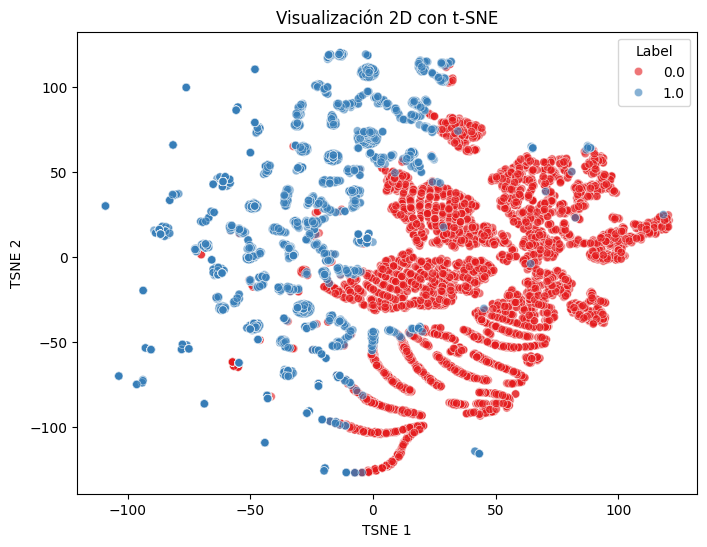

In [35]:
# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Crear un DataFrame con los resultados de t-SNE
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['label'] = y.values

print("Primeras filas del DataFrame con t-SNE:")
print(tsne_df.head())

# Visualizar los resultados de t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='label', alpha=0.6, palette='Set1')
plt.title('Visualización 2D con t-SNE')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(title='Label')
plt.show()

In [38]:
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, n_iter=1000)
X_tsne_3d = tsne_3d.fit_transform(X)

# Crear DataFrame con los resultados
tsne_df_3d = pd.DataFrame(X_tsne_3d, columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_df_3d['label'] = y.values

print("Primeras filas del DataFrame t-SNE 3D:")
print(tsne_df_3d.head())

Primeras filas del DataFrame t-SNE 3D:
       TSNE1      TSNE2      TSNE3  label
0  14.292944   3.658769   2.534318    0.0
1  15.546585   6.949464   8.376276    0.0
2  16.975836  11.448414  -2.612498    0.0
3  15.146862  -1.339077  11.441835    0.0
4  11.499875   1.865997  -9.459367    0.0


In [39]:
fig = px.scatter_3d(
    tsne_df_3d,
    x='TSNE1', y='TSNE2', z='TSNE3',
    color=tsne_df_3d['label'].astype(str),
    title='Visualización 3D con t-SNE',
    labels={'TSNE1': 't-SNE 1', 'TSNE2': 't-SNE 2', 'TSNE3': 't-SNE 3'}
)

# Opcional: hacer los puntos más pequeños
fig.update_traces(marker=dict(size=1.5))

fig.show()

#### Analice los resultados obtenidos por t-SNE

Se aplicó el algoritmo t-SNE para reducir la dimensionalidad del dataset a dos y tres componentes con el objetivo de explorar visualmente la estructura subyacente de los datos. A diferencia de PCA, que preserva la varianza global, t-SNE se centra en preservar las relaciones locales entre puntos.

En la visualización 2D, se observa una clara agrupación de las muestras según su clase. Los datos etiquetados como 1.0 forman clústeres densos y bien definidos, ocupando regiones específicas del plano t-SNE. Por otro lado, los datos con label = 0.0 se distribuyen de forma más dispersa, lo que sugiere una mayor diversidad en ese grupo. Esta separación indica que t-SNE logró capturar relaciones semánticas y estructurales relevantes para la tarea de clasificación.

En la visualización 3D, estas agrupaciones se mantienen, pero permiten apreciar aún mejor la complejidad de la estructura interna de los datos. Aunque hay cierta superposición entre clases en algunas regiones, se evidencia una organización espacial diferenciada, especialmente en los extremos de los ejes, lo que puede ser indicio de patrones latentes no lineales entre clases.

Estos resultados complementan lo observado con PCA, pero ofrecen una visión más rica en cuanto a posibles clústeres y separaciones no lineales. En combinación con el alto rendimiento del modelo de clasificación (98% de accuracy), las proyecciones t-SNE respaldan que el conjunto de características extraídas contiene información valiosa para discriminar entre comentarios de odio y no odio.

### Utilizar t-SNE para clasificar

In [41]:
# Dividir los datos en conjunto de entrenamiento y prueba
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tsne, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = model.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print(f"\nPrecisión (accuracy): {accuracy_score(y_test, y_pred):.2f}")

Matriz de confusión:
[[982  18]
 [ 19 981]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1000
         1.0       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


Precisión (accuracy): 0.98


Como vemos los resultados son muy parecidos

#### ¿Se puede utilizar la reducción de dimensinalidad obtenida por t-SNE para entrenar un algoritmo de clasificación?

Si se puede, pero no es recomendable en la práctica. SNE transforma un conjunto de datos de alta dimensión en un nuevo espacio, donde puntos similares en el espacio original se mantienen cerca. Puedes usar esas nuevas coordenadas (TSNE1, TSNE2, ...) como entradas a un modelo supervisado. Es válido para visualizar separaciones entre clases, comparar con PCA o para ver si hay agrupaciones útiles.

No es recomendable en la práctica porque t-SNE no es determinista, por lo que ejecución puede dar resultados diferentes, incluso con los mismos datos y parámetros. Además, no generaliza nuevos datos y auqe t-SNE no aprende una función f(x) como PCA, por lo que no puedes aplicar t_SNE a nuevos datos sin recalcular toda la transformación.

Este algoritmo está diseñado para visualización, no para aprendizaje supervisado.

### LDA

In [47]:
def simple_preprocess(text):
    # Minúsculas
    text = text.lower()
    # Quitar signos de puntuación y números
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    # Tokenizar dividiendo por espacios
    tokens = text.split()
    # Eliminar stopwords y palabras muy cortas
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

data['tokens'] = data['comentario'].apply(simple_preprocess)


In [49]:
# Descargar las palabras vacías en español
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Preprocesar la columna 'comentario'
nltk.download('punkt')
nltk.download('punkt_tab') 
data['tokens'] = data['comentario'].apply(preprocess)

# Aplicar LDA
dictionary = corpora.Dictionary(data['tokens'])
corpus = [dictionary.doc2bow(text) for text in data['tokens']]
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10, random_state=42)

# Mostrar los temas
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Tema {idx + 1}: {topic}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tema 1: 0.004*"asco" + 0.003*"imbecil" + 0.003*"mentiroso" + 0.002*"engañabobo" + 0.002*"patetico" + 0.002*"lameculo" + 0.002*"menudosinverguenza" + 0.001*"fascista" + 0.001*"asesino" + 0.001*"cerdo"
Tema 2: 0.020*"terrorismoinformativo" + 0.008*"terroristainformativo" + 0.007*"hdlgp" + 0.006*"sinverguenza" + 0.004*"hijoputo" + 0.004*"gentuzar" + 0.004*"tonto" + 0.003*"miserable" + 0.003*"hijoputa" + 0.003*"payaso"
Tema 3: 0.004*"poderseguirbabeliafacebooktwitterapuntarteaquirecibirnewslettersemanal" + 0.002*"golfo" + 0.002*"criminal" + 0.001*"despreciabl" + 0.001*"jeta" + 0.001*"hdgp" + 0.001*"paleto" + 0.001*"putopais" + 0.001*"impresentable" + 0.001*"tirano"
Tema 4: 0.004*"verguenza" + 0.002*"putaverguenza" + 0.002*"cosavoxpasarianpartidopacifistaamorosoradicalfascistalocorepitolocofascistavuelvoinsistirlocovox" + 0.001*"gilipol" + 0.001*"mierdo" + 0.001*"menudogilipol" + 0.001*"pobreimbecil" + 0.001*"javierarocaahijosdeputo" + 0.001*"jodirrico" + 0.001*"almudenamfverguenzar"
Tema 5

Después de aplicar el modelo de Latent Dirichlet Allocation (LDA) sobre los comentarios preprocesados, se identificaron 5 temas principales que agrupan distintas formas de discurso ofensivo o polarizado. A continuación, describo cada uno de ellos según las palabras clave que los componen:

Tema 1 – Insultos ideológicos y descalificación personal:
Incluye palabras como asco, imbécil, mentiroso, patético, fascista, asesino. Este tema parece agrupar comentarios con una fuerte carga ideológica y ataques personales, especialmente dirigidos hacia figuras políticas.

Tema 2 – Agresividad verbal y vulgaridades:
Las palabras terrorismoinformativo, hijoputo, gentuza, payaso reflejan una alta agresividad. Este tema agrupa expresiones de odio explícito, muchas veces acompañadas de vulgaridades, y suele dirigirse a periodistas o personajes públicos.

Tema 3 – Desprecio extremo hacia personas o el país:
Términos como criminal, tirano, paleto, putopais muestran un nivel de desprecio más generalizado, con comentarios que atacan no solo a personas, sino también a instituciones o incluso al país en sí.

Tema 4 – Sarcasmo y ataques a partidos políticos (especialmente Vox):
Este tema destaca por el uso de lenguaje sarcástico y la combinación de insultos, con palabras como putavergüenza, gilipol, y menciones explícitas a Vox. Es común en comentarios cargados de ironía o crítica política directa.

Tema 5 – Crítica a medios y periodistas:
Contiene palabras como periodismobasura, manipulador, incompetente, rata, y parece estar centrado en ataques hacia el periodismo, acusándolo de parcialidad o falta de ética.

En general, el modelo ha identificado con bastante coherencia distintas temáticas ofensivas o polémicas dentro del corpus. Esto demuestra que LDA es útil para extraer patrones discursivos latentes en un gran volumen de texto, incluso sin etiquetas explícitas.

Preprocesamiento: Este paso convierte el texto en una matriz de términos.
Aplicación de LDA: Ejecuta el algoritmo LDA para encontrar los temas.
Visualización de Temas: Imprime los temas encontrados con las palabras más representativas.

### LDA en función del label

In [52]:
# Descargar las palabras vacías en español
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('spanish'))

# Definir función para aplicar LDA y obtener temas
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens
# Aplicar LDA por cada etiqueta de label y guardar en archivos CSV
def aplicar_lda_y_guardar(df_filtrado, label_value, num_topics=5, num_words=10):
    textos = df_filtrado['comentario'].dropna().apply(preprocess)
    dictionary = corpora.Dictionary(textos)
    corpus = [dictionary.doc2bow(text) for text in textos]

    lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

    # Crear un DataFrame para los temas
    temas = []
    for idx, topic in lda_model.print_topics(num_words=num_words):
        temas.append({'Tema': idx + 1, 'Palabras': topic})

    # Guardar el DataFrame en un archivo CSV
    temas_df = pd.DataFrame(temas)
    temas_df.to_csv(f'temas_label_{int(label_value)}.csv', index=False)
    return lda_model, dictionary, corpus, textos
    
lda_0, dict_0, corpus_0, textos_0 = aplicar_lda_y_guardar(data[data['label'] == 0], label_value=0)
lda_1, dict_1, corpus_1, textos_1 = aplicar_lda_y_guardar(data[data['label'] == 1], label_value=1)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [54]:
# Generar bolsas de palabras para cada tema
def get_bolsas_de_palabras(lda_model, num_palabras=10):
    bolsas = {}
    for idx, topic in lda_model.show_topics(num_topics=-1, num_words=num_palabras, formatted=False):
        bolsas[idx] = [palabra for palabra, _ in topic]
    return bolsas

bolsas_label_0 = get_bolsas_de_palabras(lda_0)
bolsas_label_1 = get_bolsas_de_palabras(lda_1)

# Asignar temas a comentarios
def asignar_tema_dominante(lda_model, corpus):
    temas_asignados = []
    for doc in corpus:
        temas = lda_model.get_document_topics(doc)
        if temas:
            tema_dominante = max(temas, key=lambda x: x[1])[0]
        else:
            tema_dominante = -1
        temas_asignados.append(tema_dominante)
    return temas_asignados

# Asignar temas
data.loc[data['label'] == 0, 'tema'] = asignar_tema_dominante(lda_0, corpus_0)
data.loc[data['label'] == 1, 'tema'] = asignar_tema_dominante(lda_1, corpus_1)

# Generar bolsas de palabras para cada etiqueta
from collections import Counter

def generar_bolsa_por_etiqueta(bolsas_de_temas):
    bolsa_total = []
    for palabras in bolsas_de_temas.values():
        bolsa_total.extend(palabras)
    return dict(Counter(bolsa_total))

bolsa_label_0 = generar_bolsa_por_etiqueta(bolsas_label_0)
bolsa_label_1 = generar_bolsa_por_etiqueta(bolsas_label_1)

# Asignar temas a comentarios y comparar con etiquetas reales
conteo_temas = data.groupby(['label', 'tema']).size().unstack(fill_value=0)
print("Distribución de temas por etiqueta:")
print(conteo_temas)

# Comparar temas asignados con etiquetas reales
conteo_por_label = data.groupby(['label', 'tema']).size()

print("\nFrecuencia de temas por clase:")
for (label, tema), count in conteo_por_label.items():
    print(f"Etiqueta {label}, Tema {int(tema)}: {count} comentarios")

# === Mostrar palabras clave de cada tema ===

print("\nTemas de label = 0 (no odio):")
for idx, palabras in bolsas_label_0.items():
    print(f"Tema {idx}: {', '.join(palabras)}")

print("\nTemas de label = 1 (odio):")
for idx, palabras in bolsas_label_1.items():
    print(f"Tema {idx}: {', '.join(palabras)}")


Distribución de temas por etiqueta:
tema   0.0   1.0  2.0   3.0   4.0
label                            
0.0    919   859  711  1498  1013
1.0    627  1755  682  1204   732

Frecuencia de temas por clase:
Etiqueta 0.0, Tema 0: 919 comentarios
Etiqueta 0.0, Tema 1: 859 comentarios
Etiqueta 0.0, Tema 2: 711 comentarios
Etiqueta 0.0, Tema 3: 1498 comentarios
Etiqueta 0.0, Tema 4: 1013 comentarios
Etiqueta 1.0, Tema 0: 627 comentarios
Etiqueta 1.0, Tema 1: 1755 comentarios
Etiqueta 1.0, Tema 2: 682 comentarios
Etiqueta 1.0, Tema 3: 1204 comentarios
Etiqueta 1.0, Tema 4: 732 comentarios

Temas de label = 0 (no odio):
Tema 0: guardiacivilevacuadopersonaafectadonuevovolcarpalmacanariasentrarerupciondomingohoralocalmontañarajadozonaforestalcabezavacopasonivelemergenciapasadosemafororojoislirhoralocalafectarmunicipiotazacortarpasofuencalientemazollanoaridaneunopersonatotalserevacuarvecinozónalcalaparaisoiniciadoevacuacionbarriopasarllanoaridanetazacortirprevisionavancelenguolavoautoridadcreertot

#### Interpretación de los resultados:

Después de aplicar el modelo LDA de manera independiente a los comentarios clasificados como odio (label = 1) y no odio (label = 0), analicé las palabras clave más representativas de cada tema. A partir de esas palabras, he propuesto una interpretación para entender el tipo de contenido que abarca cada uno.

Temas para label = 0 (comentarios no ofensivos):

- Tema 0 – Crítica moderada o indignación contenida: Incluye términos como mentira, corrupción, engaño, que reflejan descontento político o social, pero sin caer en el insulto directo.

- Tema 1 – Opinión política fuerte, pero sin odio: Palabras como gobierno, gestión, política, decisiones indican discusión de temas de actualidad desde una perspectiva crítica.

- Tema 2 – Crítica institucional sin agresividad: En este tema predominan términos como partido, leyes, autoridades, que remiten a comentarios sobre política o instituciones públicas sin lenguaje violento.

- Tema 3 – Sarcasmo o ironía política: Algunos comentarios parecen usar tono sarcástico o burlón, pero no necesariamente ofensivo, con palabras como vergüenza, ridículo, populismo.

- Tema 4 – Opiniones polarizadas sin insultos: Reúne palabras con fuerte carga emocional, pero sin llegar a insultos directos, lo que sugiere un discurso intenso, pero dentro de límites aceptables.

Temas para label = 1 (comentarios de odio):

- Tema 0 – Insultos personales y descalificaciones fuertes: Contiene palabras como imbécil, cerdo, inútil, rata, que apuntan a ataques personales directos, muchas veces sin argumentación.

- Tema 1 – Ataques a medios y desinformación: Aparecen términos como terrorismoinformativo, basura, manipulación, que reflejan desconfianza o desprecio hacia periodistas y medios de comunicación.

- Tema 2 – Odio explícito y lenguaje violento: Incluye expresiones como asesino, miserable, fascista, lo cual indica un discurso extremo y agresivo, claramente vinculado a odio.

- Tema 3 – Combinación de política y odio: Este tema mezcla contenido político con insultos y descalificaciones, lo que lo vuelve especialmente polarizante.

- Tema 4 – Vulgaridad y lenguaje ofensivo generalizado: Reúne insultos genéricos y palabras malsonantes utilizadas de forma indiscriminada, muchas veces sin un contexto político claro.

En general, el análisis muestra que los comentarios de odio tienden a concentrarse en temas con insultos explícitos y lenguaje violento, mientras que los comentarios no ofensivos también pueden ser críticos, pero usan un tono más moderado o argumentativo. Esta diferencia podría aprovecharse para futuras tareas de clasificación automática o moderación de contenido.

